In [2]:
%load_ext itikz

(content:design)=
# Thiết kế các thử nghiệm và dự án trong công nghệ tiếng nói (Design of Experiments and Projects)

Các dự án trong xử lý hoặc công nghệ tiếng nói có cấu trúc tương đối giống với các dự án kỹ thuật nói chung, và do đó các kiến thức này thường được giảng dạy trong các khóa học lập kế hoạch dự án thông thường, chẳng hạn như trên [Coursera](https://www.coursera.org/learn/uva-darden-project-management). Tuy nhiên, việc xem xét các dự án dưới góc độ xử lý tiếng nói sẽ giúp cụ thể hóa chi tiết hơn về *cách thức* lựa chọn các yêu cầu kỹ thuật và các thử nghiệm. Ngoài ra, phần này phác thảo một quy trình làm việc tổng quát cho tất cả các thử nghiệm trong xử lý tiếng nói. Định dạng này áp dụng cho mọi dự án công nghệ tiếng nói và ngôn ngữ, nhưng mang lại giá trị cao nhất đối với các dự án mà chất lượng đầu ra được đánh giá bởi con người, chẳng hạn như khi sử dụng [đánh giá chất lượng chủ quan](content:subjectiveevaluation).

Quy trình tổng quát được minh họa bên dưới. Chuỗi sự kiện lý tưởng (nhưng rất ít khi xảy ra trong thực tế) là đi thẳng từ trên xuống dưới theo từng bước. Một quy trình thực tế hơn, và thường cải thiện đáng kể chất lượng sản phẩm cuối cùng, là lặp đi lặp lại giữa các bước, ví dụ: giữa khâu triển khai mã nguồn và khâu kiểm thử. Trong hình dưới, các vòng lặp đặc trưng và thường gặp được minh họa bằng màu xám đậm, trong khi các hướng đi ít xảy ra hơn được vẽ bằng màu xám nhạt.

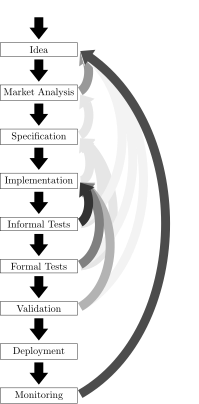

In [132]:
%%itikz --temp-dir  --file-prefix anonsolve 
\documentclass[tikz]{standalone}
\usepackage[utf8]{inputenc}
\usepackage{tikz}
\usepackage{verbatim}


\usepackage{pgfplots}
\DeclareUnicodeCharacter{2212}{−}
\usepgfplotslibrary{groupplots,dateplot}
\usetikzlibrary{patterns,shapes.arrows}
\usetikzlibrary {fit} 
\usetikzlibrary{shapes.geometric,positioning}
\usetikzlibrary{bending}
\pgfplotsset{compat=newest}

\usetikzlibrary{arrows.meta}
\usetikzlibrary{arrows}

\tikzstyle{arrow}   = [solid, line width = 9pt, -{Triangle[width = 18pt, length = 12pt]}, color = black, shorten >= 3pt, shorten <= 3pt]

\begin{document}


\begin{tikzpicture}[scale=1,transform shape]
    \node[] (null) {\parbox{2.5cm}{\centering\phantom{Null}}};
    \node[draw,below=of null] (idea) {\parbox{2.5cm}{\centering Idea}};
    \node[draw,below=of idea] (market) {\parbox{2.5cm}{\centering Market Analysis}};
    \node[draw,below=of market] (spec) {\parbox{2.5cm}{\centering Specification}};
    \node[draw,below=of spec] (coding) {\parbox{2.5cm}{\centering Implementation}};
    \node[draw,below=of coding] (test1) {\parbox{2.5cm}{\centering Informal Tests}};
    \node[draw,below=of test1] (test2) {\parbox{2.5cm}{\centering Formal Tests}};
    \node[draw,below=of test2] (test3) {\parbox{2.5cm}{\centering Validation}};
    \node[draw,below=of test3] (deploy) {\parbox{2.5cm}{\centering Deployment}};
    \node[draw,below=of deploy] (monitor) {\parbox{2.5cm}{\centering Monitoring}};
    
    \draw[arrow] (null) -- (idea);
    \draw[arrow] (idea) -- (market);
    \draw[arrow] (market) -- (spec);
    \draw[arrow] (spec) -- (coding);
    \draw[arrow] (coding) -- (test1);
    \draw[arrow] (test1) -- (test2);
    \draw[arrow] (test2) -- (test3);
    \draw[arrow] (test3) -- (deploy);
    \draw[arrow] (deploy) -- (monitor);
    
    \draw[arrow,color=black!40!white,out=30,in=-30] (market.east) to (idea.east);
    \draw[arrow,color=black!10!white,out=30,in=-30] (spec.east) to (market.east);
    \draw[arrow,color=black!10!white,out=5,in=-30] (coding.east) to (spec.east);
    \draw[arrow,color=black!10!white,out=5,in=-30] (test1.east) to (spec.east);
    \draw[arrow,color=black!10!white,out=5,in=-30] (test2.east) to (spec.east);
    \draw[arrow,color=black!5!white,out=30,in=-30] (test3.east) to (idea.east);
    \draw[arrow,color=black!5!white,out=30,in=-30] (test2.east) to (idea.east);
    \draw[arrow,color=black!5!white,out=30,in=-30] (test1.east) to (idea.east);
    \draw[arrow,color=black!30!white,out=30,in=-30] (test3.east) to (coding.east);
    \draw[arrow,color=black!50!white,out=30,in=-30] (test2.east) to (coding.east);
    \draw[arrow,color=black!80!white,out=30,in=-30] (test1.east) to (coding.east);
    \draw[arrow,color=black!70!white,out=30,in=-30] (monitor.east) to (idea.east);
    
\end{tikzpicture}


\end{document}

## Ý tưởng (Idea)
Mọi thứ đều bắt đầu với một ý tưởng về một vấn đề cần giải quyết hoặc một tính năng có thể được cải tiến hoặc giới thiệu mới.

## Phân tích thị trường (Market Analysis)
Trước khi đầu tư công sức phát triển một tính năng mới hoặc giải quyết một vấn đề, điều cần thiết là phải biết liệu có ai quan tâm đến nó hay không. *Tại sao tính năng này quan trọng? Kết quả của dự án này sẽ cải thiện cuộc sống của người dùng như thế nào? Đây có phải là thứ chúng ta có thể thương mại hóa được không?*

Nếu câu trả lời là *không*, tức là nó không quan trọng, chúng ta sẽ dừng lại hoặc quay lại bước hình thành ý tưởng.

## Xác định yêu cầu kỹ thuật (Specification)
Trong khâu xác định yêu cầu kỹ thuật, chúng ta lựa chọn tất cả các tham số liên quan của dự án, bao gồm:
- *nhóm mục tiêu (target group)*; tính năng này được thiết kế cho ai?
- *chỉ số đánh giá (metrics)*; thành công được định nghĩa như thế nào?
- *phương pháp (methods)*; hướng tiếp cận chính là gì?
- *mức đối chuẩn (baseline)*; nếu chúng ta đang cải tiến một tính năng, mức chất lượng tham chiếu là gì?
- *tập dữ liệu (dataset)*; những dữ liệu nào chúng ta có thể sử dụng để huấn luyện mô hình và đánh giá hiệu năng?
- *tăng cường dữ liệu (augmentation)*; nếu nguồn cung cấp dữ liệu bị hạn chế, làm thế nào chúng ta có thể tăng kích thước tập huấn luyện một cách nhân tạo?
- *yêu cầu hệ thống (requirements)*; các thuộc tính bắt buộc của một giải pháp là gì?
- *môi trường triển khai (implementation)*; chúng ta sẽ sử dụng nền tảng phần cứng và phần mềm nào?
- *môi trường sử dụng (use)*; dịch vụ sẽ được sử dụng trong những môi trường vật lý nào?
- v.v.

Phần phân tích thị trường trước đó cần đưa ra câu trả lời cho các câu hỏi này, nếu không, chúng ta buộc phải thực hiện lại phân tích đó.

## Triển khai (Implementation)
Cuối cùng chúng ta có thể bắt đầu lập trình.

> **Lời khuyên từ chuyên gia:** Hãy bắt đầu bằng cách triển khai một chương trình nhỏ nhất có thể để cho ra đầu ra hợp lý. Ví dụ, nếu ứng dụng mong muốn tạo ra âm thanh đầu ra, hãy triển khai mã nguồn phát được một âm thanh. Kiểm thử nó (một cách không chính thức). Bắt đầu thêm các tính năng theo từng bước cực kỳ nhỏ, và liên tục kiểm tra xem đầu ra có duy trì được tính hợp lý hay không.

## Kiểm thử và xác thực không chính thức (Informal testing and validation)
Hầu như không có ai lập trình một thứ gì đó hoạt động hoàn hảo ngay từ lần thử đầu tiên. Lập trình do đó là một quá trình lặp đi lặp lại nơi chúng ta viết mã và kiểm thử nó. Chúng ta càng nhận được kết quả kiểm thử hữu ích nhanh bao nhiêu, chúng ta càng nhanh chóng quay lại sửa lỗi bấy nhiêu. Do đó, điều quan trọng là các bài kiểm thử cấp độ đầu tiên phải chạy nhanh và chi phí thấp.

### Kiểm tra tính hợp lý (Sanity checks) / xác thực
- Khi triển khai học máy, thông thường bạn muốn quan sát thấy giá trị của hàm mất mát hội tụ về một giá trị hợp lý.
- Hãy vẽ đồ thị dạng sóng (waveform) hoặc phổ biên độ (spectrogram) của đầu ra và kiểm tra xem nó có trông giống như mong đợi hay không.
- Nếu chương trình/hàm xuất ra âm thanh, **Hãy nghe thử âm thanh đầu ra! Điều này cực kỳ quan trọng!** Một tỷ lệ rất lớn các lỗi lập trình có thể được phát hiện đơn giản bằng cách nghe thử âm thanh. Bạn cũng sẽ nhanh chóng học được cách mô tả định tính hiệu năng của hệ thống. Điều này định hướng rất tốt cho các phát triển tiếp theo của bạn.

### Kiểm thử quy mô nhỏ (Small-scale tests)
- Chạy các bài [kiểm thử chất lượng khách quan (objective quality tests)](content:objectiveevaluation) và/hoặc [các thước đo hiệu năng khác](content:otherperformance) và thực hiện nhanh [phân tích kết quả](content:analysisofresults).

### và sau đó...
Thông thường, bạn sẽ phát hiện ra một vấn đề hoặc một điểm cần cải tiến ngay trong quá trình kiểm thử không chính thức, giúp bạn có thể quay lại sửa chữa mã nguồn (triển khai).

Sau một số lượng vòng lặp đủ lớn, khi chất lượng đã đủ tốt, bạn có thể chuyển sang bước kiểm thử chất lượng chính thức.

## Kiểm thử chất lượng chính thức (Formal quality test)
Nếu các bài kiểm thử không chính thức cho thấy hiệu năng tốt, bạn đã sẵn sàng đánh giá hiệu năng bằng một quy trình kiểm thử nghiêm ngặt hơn. Thông thường, khi đó bạn sẽ muốn so sánh hiệu năng hệ thống của mình với (các) phương pháp đối chuẩn (baseline), chẳng hạn như phiên bản trước đó của phần mềm hoặc các thuật toán cạnh tranh khác. Với các bài kiểm thử khách quan, bạn có thể đánh giá hiệu năng trên các tập dữ liệu lớn. Khi phù hợp, bạn cũng có thể đánh giá hiệu năng chủ quan bằng các bài [kiểm thử nghe chính thức (listening tests)](content:subjectiveevaluation) quy mô nhỏ. Trong cả hai trường hợp, ở giai đoạn này, bạn đã cần thực hiện các phép [phân tích kết quả](content:analysisofresults) thống kê phù hợp.

Một kịch bản điển hình là bạn sẽ nhờ đồng nghiệp hoặc bạn bè thực hiện một bài kiểm thử nghe dài 15 phút. Đó là điều bạn có thể làm khoảng hai tuần một lần hoặc mỗi tháng một lần để giữ mối quan hệ tốt với bạn bè của mình. Việc này về lâu dài sẽ gây nhàm chán cho những người tham gia đánh giá.

Các bài kiểm thử chính thức được sử dụng để định hướng phát triển tiếp theo. Khi không có đủ bằng chứng chứng minh hiệu năng đạt yêu cầu, chúng ta phải quay lại cải tiến phần triển khai mã nguồn.

> **Lời khuyên từ chuyên gia:** Sẽ rất hữu ích nếu trích xuất các mẫu dữ liệu có chỉ số hiệu năng khách quan tệ nhất. Sau đó, chúng ta có thể cố gắng đánh giá các mẫu đó bằng tai và bằng cảm nhận để tìm ra nguyên nhân gây ra chất lượng kém. Điều này đặc biệt hiệu quả để phát hiện các lỗi lập trình hiếm khi xảy ra.

## Xác thực (Validation)

Trong bất kỳ ứng dụng quan trọng nào, chúng ta cần bằng chứng vững chắc rằng các chức năng được đề xuất hoạt động đúng như quảng cáo. Để có được bằng chứng đó, chúng ta sử dụng *các bài kiểm thử xác thực*. Trong các dịch vụ có âm thanh đầu ra (như nén hoặc nâng cao chất lượng tiếng nói), các bài kiểm thử này thường đòi hỏi các cuộc kiểm thử nghe chủ quan với một tập hợp người nghe lớn hơn (hàng trăm hoặc hàng nghìn người nghe). Khi chức năng là một phần của giao diện người dùng, chúng ta cũng cần các bài kiểm thử nơi người dùng trực tiếp sử dụng dịch vụ. Các bài kiểm thử như vậy là tiêu chuẩn trong thiết kế giao diện người dùng, và điểm khác biệt chính so với các bài kiểm thử nghe chủ quan là các bài kiểm thử sử dụng thường cần được thiết kế riêng cho từng trường hợp sử dụng cụ thể. Do đó, số lượng người dùng có thể đánh giá sẽ nhỏ hơn một bậc quy mô.

Trong các ứng dụng phân tích tiếng nói, nơi đầu ra không phải là âm thanh mà là một *kết quả phân tích*, rõ ràng chúng ta cần các thước đo hiệu năng khách quan. Thước đo này thường rất giống với hàm mất mát của bài toán học máy tương ứng. Sự khác biệt chính giữa khâu huấn luyện/kiểm thử so với xác thực là tập dữ liệu xác thực phải là tập dữ liệu *chưa từng thấy trước đó (previously unseen)* và đủ lớn.

Trong mọi trường hợp, kết quả của các bài kiểm thử xác thực phải được phân tích bằng [các công cụ thống kê](content:analysisofresults) để xác định mức độ tin cậy thống kê mà chúng ta có thể đặt vào các kết quả thu được.

Một khi chúng ta có đủ bằng chứng cho thấy phương pháp đề xuất đạt chất lượng tốt/đủ cao, chúng ta có thể tiến hành triển khai thực tế.

## Triển khai thực tế (Deployment)

Phần mềm hoặc dịch vụ đã phát triển sau đó sẽ được đưa vào sử dụng trong một nền tảng thế giới thực.

## Giám sát (Monitoring)

Một khi phần mềm hoặc dịch vụ được đưa vào sử dụng, chúng ta nên liên tục giám sát hiệu năng của nó. Ví dụ, chúng ta có thể định kỳ kiểm tra chất lượng cảm nhận khách quan để phát hiện các lỗi phần mềm hoặc lỗi phần cứng. Chúng ta có thể phân tích các mô hình sử dụng để tìm hiểu tính năng nào được người dùng ưa chuộng. Hoạt động giám sát này đóng vai trò trung tâm trong việc thấu hiểu nhu cầu của khách hàng, từ đó nuôi dưỡng các ý tưởng cải tiến mới.